In [1]:
from pathlib import Path
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [ ]:
BERTOPIC_DATA_DIR = Path('/mimer/NOBACKUP/groups/naiss2024-6-297/cache/bertopic_data/bertopic_inputs')
CACHE_DIR = Path('/mimer/NOBACKUP/groups/naiss2024-6-297/cache/bertopic_bootstrapped/full_training_10')
TRAIN_MODEL_DIR = CACHE_DIR / 'models'
INFERENCE_DIR = CACHE_DIR / 'inference'
NR_TOPICS_LIST = list(range(5, 85, 5))  # [5, 10, 15, ..., 80]
N_BOOTSTRAPS = 10

# ── Load full-dataset metadata + texts ──
metadata = pd.read_csv(BERTOPIC_DATA_DIR / 'all_stories_metadata.csv')
with open(BERTOPIC_DATA_DIR / 'all_stories_texts.json', 'r') as f:
    stories = json.load(f)

print(f'Stories: {len(stories)}, Metadata rows: {len(metadata)}')
print(f'Columns: {list(metadata.columns)}')
metadata.head()

Stories: 1440, Metadata rows: 1440
Columns: ['story_index', 'doc_key', 'story_id', 'model_type', 'prompt_type', 'seed', 'num_story_images', 'source_file']


,story_index,doc_key,story_id,model_type,prompt_type,seed,num_story_images,source_file
0,0,2926,0,claude45,large,42,5,claude45_large_seed42_test_snapshots__local_js...
1,1,8551,1,claude45,large,42,8,claude45_large_seed42_test_snapshots__local_js...
2,2,6847,2,claude45,large,42,5,claude45_large_seed42_test_snapshots__local_js...
3,3,8061,3,claude45,large,42,8,claude45_large_seed42_test_snapshots__local_js...
4,4,11340,4,claude45,large,42,5,claude45_large_seed42_test_snapshots__local_js...


In [87]:
# ── Build sentence-level mapping ──
def build_sentence_mapping(stories, metadata):
    rows = []
    current_idx = 0
    for doc_id, doc in enumerate(stories):
        sentences = [s.strip() for s in doc.split('[SENT]') if s.strip()]
        meta = metadata[metadata['story_index'] == doc_id].iloc[0]
        for pos, sent in enumerate(sentences):
            rows.append({
                'sentence_idx': current_idx, 'sentence_pos': pos,
                'sentence_text': sent,
                'n_sentences': len(sentences), 'story_index': doc_id,
                'story_id': meta['doc_key'],
                'model_type': meta['model_type'],
                'prompt_type': meta['prompt_type'],
                'seed': meta['seed'],
            })
            current_idx += 1
    return pd.DataFrame(rows)

def filter_by_seed(df):
    """Filter to canonical seed selections:
    - original prompt: seed=42 only
    - large prompt, AI models: seed=42 only
    - large prompt, human: all seeds (42, 43, 44)
    """
    original = df[(df['prompt_type'] == 'original') & (df['seed'] == 42)]
    large_ai = df[(df['prompt_type'] == 'large') & (df['model_type'] != 'human') & (df['seed'] == 42)]
    large_human = df[(df['prompt_type'] == 'large') & (df['model_type'] == 'human')]
    return pd.concat([original, large_ai, large_human], ignore_index=True)

sent_map = build_sentence_mapping(stories, metadata)
print(f'Total sentences: {len(sent_map)}')
sent_map_filtered = filter_by_seed(sent_map)
print(f'Filtered sentences (seed rules): {len(sent_map_filtered)}')
sent_map.head()

Total sentences: 8407
Filtered sentences (seed rules): 4865


,sentence_idx,sentence_pos,sentence_text,n_sentences,story_index,story_id,model_type,prompt_type,seed
0,0,0,"At an upscale bar or social gathering , a man ...",5,0,2926,claude45,large,42
1,1,1,"Meanwhile , at what appears to be the same eve...",5,0,2926,claude45,large,42
2,2,2,"Back at the bar , Jeff in his distinctive oran...",5,0,2926,claude45,large,42
3,3,3,The conversation intensifies as Jeff leans in ...,5,0,2926,claude45,large,42
4,4,4,"Jeff stands confidently at the bar , his hands...",5,0,2926,claude45,large,42


In [ ]:
available_train = []
available_infer = []

for b in range(N_BOOTSTRAPS):
    for nt in NR_TOPICS_LIST:
        model_dir = TRAIN_MODEL_DIR / f'bootstrap_{b:02d}' / f'topics_{nt}'
        infer_dir = INFERENCE_DIR / f'bootstrap_{b:02d}' / f'topics_{nt}'
        if model_dir.exists() and (model_dir / 'topic_info.csv').exists():
            available_train.append((b, nt))
        if infer_dir.exists() and (infer_dir / 'sentence_topics.npy').exists():
            available_infer.append((b, nt))

print(f'Trained models available: {len(available_train)} / {N_BOOTSTRAPS * len(NR_TOPICS_LIST)}')
print(f'Inference results available: {len(available_infer)} / {N_BOOTSTRAPS * len(NR_TOPICS_LIST)}')

# completion grid
train_grid = pd.DataFrame(0, index=range(N_BOOTSTRAPS), columns=NR_TOPICS_LIST)
infer_grid = pd.DataFrame(0, index=range(N_BOOTSTRAPS), columns=NR_TOPICS_LIST)
for b, nt in available_train:
    train_grid.loc[b, nt] = 1
for b, nt in available_infer:
    infer_grid.loc[b, nt] = 1

print('\nTraining completion (rows=bootstrap, cols=nr_topics):')
display(train_grid)
print('\nInference completion:')
display(infer_grid)

Trained models available: 160 / 160
Inference results available: 160 / 160

Training completion (rows=bootstrap, cols=nr_topics):


,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
7,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
8,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
9,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1



Inference completion:


,5,10,15,20,25,30,35,40,45,50,55,60,65,70,75,80
0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
6,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
7,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
8,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
9,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [68]:
# ── Pick a config to inspect ──
BOOTSTRAP = 0
NR_TOPICS = 80

topic_info_path = TRAIN_MODEL_DIR / f'bootstrap_{BOOTSTRAP:02d}' / f'topics_{NR_TOPICS}' / 'topic_info.csv'

if not topic_info_path.exists():
    print(f'Not found: {topic_info_path}')
else:
    topic_info = pd.read_csv(topic_info_path)
    print(f'bootstrap={BOOTSTRAP}, nr_topics={NR_TOPICS}')
    print(f'Topics (incl outlier -1): {len(topic_info)}')
    print(f'Columns: {list(topic_info.columns)}')
    print()

    # Parse top words from Name column
    def extract_top_words(name, max_words=20):
        if pd.isna(name):
            return ''
        parts = str(name).split('_')
        if len(parts) > 1:
            return ', '.join(parts[1:1+max_words])
        return str(name)

    topic_info['TopWords'] = topic_info['Name'].apply(extract_top_words)

    display_cols = ['Topic', 'Count']
    if 'Name' in topic_info.columns:
        display_cols.append('Name')
    display_cols.append('TopWords')

    with pd.option_context('display.max_colwidth', None):
        display(topic_info[display_cols])

bootstrap=0, nr_topics=80
Topics (incl outlier -1): 80
Columns: ['Unnamed: 0', 'Topic', 'Count', 'Name', 'Representation', 'Representative_Docs']



,Topic,Count,Name,TopWords
0,-1,689,-1_the_to_of_and,"the, to, of, and"
1,0,319,0_crowd_people_image_of,"crowd, people, image, of"
2,1,113,1_ben_dog_cameron_lin,"ben, dog, cameron, lin"
3,2,106,2_tom_bill_jean_message,"tom, bill, jean, message"
4,3,99,3_shea_christian_bradley_suit,"shea, christian, bradley, suit"
...,...,...,...,...
75,74,11,74_brian_dimly_lit_older,"brian, dimly, lit, older"
76,75,11,75_curly_camp_she_chaos,"curly, camp, she, chaos"
77,76,11,76_gerard_jennifer_important_catch,"gerard, jennifer, important, catch"
78,77,11,77_movie_theater_woman_engrossed,"movie, theater, woman, engrossed"


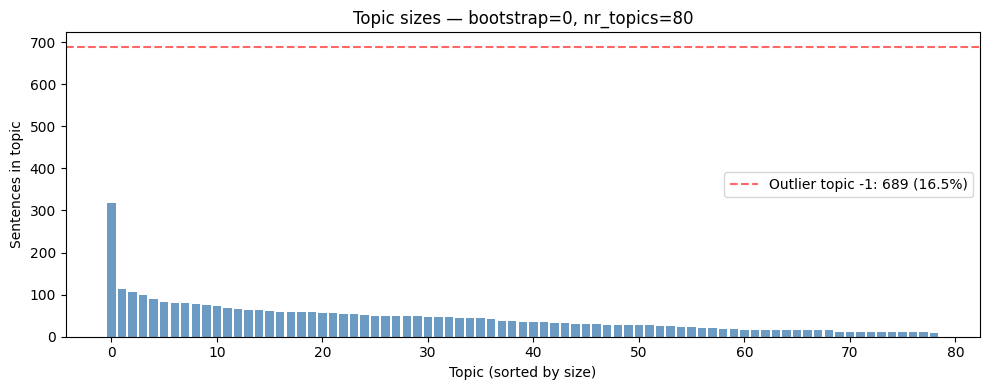

In [39]:
# ── Topic size distribution for this config ──
if topic_info_path.exists():
    main_topics = topic_info[topic_info['Topic'] != -1]
    outlier_row = topic_info[topic_info['Topic'] == -1]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(len(main_topics)), main_topics['Count'].values, color='steelblue', alpha=0.8)
    ax.set_xlabel('Topic (sorted by size)')
    ax.set_ylabel('Sentences in topic')
    ax.set_title(f'Topic sizes — bootstrap={BOOTSTRAP}, nr_topics={NR_TOPICS}')

    if not outlier_row.empty:
        outlier_count = int(outlier_row['Count'].iloc[0])
        total = int(topic_info['Count'].sum())
        ax.axhline(y=outlier_count, color='red', linestyle='--', alpha=0.6,
                   label=f'Outlier topic -1: {outlier_count} ({outlier_count/total:.1%})')
        ax.legend()

    fig.tight_layout()
    plt.show()

In [40]:
# ── Pick a story to inspect ──
STORY_ID = 10408          # change to any story_id
MODEL_TYPE = 'human'   # model_type from metadata
PROMPT_TYPE = 'large'
SEED = 44
BOOTSTRAP = 0
NR_TOPICS = 80

# Load inference sentence topics
infer_path = INFERENCE_DIR / f'bootstrap_{BOOTSTRAP:02d}' / f'topics_{NR_TOPICS}' / 'sentence_topics.npy'
topic_info_path_inspect = TRAIN_MODEL_DIR / f'bootstrap_{BOOTSTRAP:02d}' / f'topics_{NR_TOPICS}' / 'topic_info.csv'

if not infer_path.exists():
    print(f'Inference not found: {infer_path}')
else:
    sentence_topics = np.load(infer_path)

    # Load topic info for names/top words
    topic_name_map = {}
    topic_words_map = {}
    if topic_info_path_inspect.exists():
        ti = pd.read_csv(topic_info_path_inspect)
        for _, row in ti.iterrows():
            tid = row['Topic']
            name = str(row.get('Name', ''))
            parts = name.split('_')
            top_words = ', '.join(parts[1:21]) if len(parts) > 1 else name
            topic_name_map[tid] = name
            topic_words_map[tid] = top_words

    # Find the story's sentences
    story_sents = sent_map[
        (sent_map['story_id'].astype(str) == str(STORY_ID))
        & (sent_map['model_type'] == MODEL_TYPE)
        & (sent_map['prompt_type'] == PROMPT_TYPE)
        & (sent_map['seed'] == SEED)
    ].sort_values('sentence_pos').copy()

    if story_sents.empty:
        print(f'No sentences found for story_id={STORY_ID}, model={MODEL_TYPE}, prompt={PROMPT_TYPE}, seed={SEED}')
    else:
        story_sents['topic'] = sentence_topics[story_sents['sentence_idx'].values]
        story_sents['topic_name'] = story_sents['topic'].map(topic_name_map).fillna('')
        story_sents['top_words'] = story_sents['topic'].map(topic_words_map).fillna('')

        print(f'Story {STORY_ID} | {MODEL_TYPE} / {PROMPT_TYPE} / seed={SEED}')
        print(f'bootstrap={BOOTSTRAP}, nr_topics={NR_TOPICS}')
        print(f'Sentences: {len(story_sents)}, Unique topics assigned: {story_sents["topic"].nunique()}')
        print()

        # Show each sentence with its topic, name, and top words
        with pd.option_context('display.max_colwidth', None, 'display.max_columns', None, 'display.width', None, 'display.max_rows', None):
            display(story_sents[['sentence_pos', 'topic', 'topic_name', 'top_words', 'sentence_text']])

Story 10408 | human / large / seed=44
bootstrap=0, nr_topics=80
Sentences: 5, Unique topics assigned: 3



,sentence_pos,topic,topic_name,top_words,sentence_text
3498,0,33,33_jake_greta_park_picnic,"jake, greta, park, picnic",Greta is putting on another one of those Yacht parties that everyone is talking about . They attract some of the normal types of characters . Including Jake .
3499,1,42,42_jason_piano_nick_bar,"jason, piano, nick, bar","Jake is your typical ladies man , who is always trying to woo anyone willing to listen . There is a problem though ."
3500,2,33,33_jake_greta_park_picnic,"jake, greta, park, picnic","Greta has a man already . And not at all in the mood to be `` woo'ed '' today . So she picks up her phone and auto dials . As the listens to Jake 's sales pitch . The same old tired noise , with a hint of creeper to it ."
3501,3,69,69_ashton_park_harbor_gathering,"ashton, park, harbor, gathering","Ashton , Great 's boyfriend , arrives on site just as expected . No traffic excuses today ."
3502,4,33,33_jake_greta_park_picnic,"jake, greta, park, picnic","Just as he is about to move in to make sure the rules of engagement are laid out plainly for Jake , he gets a text . It 's Greta , she is calling off the rescue . Seems Jake has gotten the message in the nick of time . Guess Ashton will just have to go find a tv and beer to watch ."


/tmp/ipykernel_2185557/3141585278.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(len(unique_topics), 1))


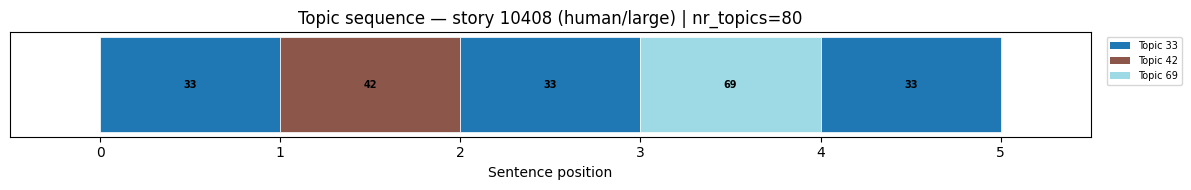

In [41]:
# ── Visualise topic sequence for the story ──
if infer_path.exists() and not story_sents.empty:
    topics_seq = story_sents['topic'].values
    positions = story_sents['sentence_pos'].values
    unique_topics = sorted(set(topics_seq))

    # Color map
    cmap = plt.cm.get_cmap('tab20', max(len(unique_topics), 1))
    topic_to_color = {t: cmap(i) for i, t in enumerate(unique_topics)}
    colors = [topic_to_color[t] for t in topics_seq]

    fig, ax = plt.subplots(figsize=(max(12, len(topics_seq) * 0.5), 2))
    ax.barh(0, width=1, left=positions, color=colors, edgecolor='white', linewidth=0.5,
            height=0.8)

    # Label each bar with topic id
    for pos, t in zip(positions, topics_seq):
        ax.text(pos + 0.5, 0, str(t), ha='center', va='center', fontsize=7, fontweight='bold')

    ax.set_xlim(-0.5, len(topics_seq) + 0.5)
    ax.set_xlabel('Sentence position')
    ax.set_yticks([])
    ax.set_title(f'Topic sequence — story {STORY_ID} ({MODEL_TYPE}/{PROMPT_TYPE}) | nr_topics={NR_TOPICS}')

    # Legend
    from matplotlib.patches import Patch
    legend_patches = [Patch(facecolor=topic_to_color[t], label=f'Topic {t}') for t in unique_topics]
    ax.legend(handles=legend_patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)

    fig.tight_layout()
    plt.show()

In [42]:
# ── Topic assignments across nr_topics for one story ──
STORY_ID_CMP = 10408
MODEL_TYPE_CMP = 'human'
PROMPT_TYPE_CMP = 'large'
SEED_CMP = 42
BOOTSTRAP_CMP = 0

story_sents_base = sent_map[
    (sent_map['story_id'].astype(str) == str(STORY_ID_CMP))
    & (sent_map['model_type'] == MODEL_TYPE_CMP)
    & (sent_map['prompt_type'] == PROMPT_TYPE_CMP)
    & (sent_map['seed'] == SEED_CMP)
].sort_values('sentence_pos').copy()

if story_sents_base.empty:
    print('Story not found.')
else:
    n_sents = len(story_sents_base)
    sent_indices = story_sents_base['sentence_idx'].values

    # Collect topic assignments per nr_topics
    rows_nt = []
    for nt in NR_TOPICS_LIST:
        ip = INFERENCE_DIR / f'bootstrap_{BOOTSTRAP_CMP:02d}' / f'topics_{nt}' / 'sentence_topics.npy'
        if not ip.exists():
            continue
        topics = np.load(ip)
        for pos, sidx in enumerate(sent_indices):
            rows_nt.append({'nr_topics': nt, 'sentence_pos': pos, 'topic': int(topics[sidx])})

    df_nt = pd.DataFrame(rows_nt)

    if df_nt.empty:
        print('No inference results found.')
    else:
        # Pivot: rows = nr_topics, columns = sentence_pos
        pivot = df_nt.pivot(index='nr_topics', columns='sentence_pos', values='topic')

        # Count topic switches per nr_topics
        switches = []
        for nt in pivot.index:
            seq = pivot.loc[nt].values
            n_changes = sum(1 for i in range(len(seq) - 1) if seq[i] != seq[i+1])
            switches.append({'nr_topics': nt, 'n_switches': n_changes,
                             'switch_rate': np.tanh(n_changes / (len(seq) - 1)) if len(seq) > 1 else 0})
        switches_df = pd.DataFrame(switches)

        print(f'Story {STORY_ID_CMP} ({MODEL_TYPE_CMP}/{PROMPT_TYPE_CMP}), {n_sents} sentences')
        print(f'bootstrap={BOOTSTRAP_CMP}')
        print()
        print('Topic switches by nr_topics:')
        display(switches_df)
        print()
        print('Topic assignments (rows=nr_topics, cols=sentence_pos):')
        with pd.option_context('display.max_columns', None):
            display(pivot)

Story 10408 (human/large), 6 sentences
bootstrap=0

Topic switches by nr_topics:


,nr_topics,n_switches,switch_rate
0,5,3,0.537050
1,10,2,0.379949
2,15,3,0.537050
3,20,4,0.664037
4,25,3,0.537050
5,30,1,0.197375
6,35,1,0.197375
7,40,3,0.537050
8,45,2,0.379949
9,50,1,0.197375



Topic assignments (rows=nr_topics, cols=sentence_pos):


sentence_pos,0,1,2,3,4,5
nr_topics,,,,,,
5,0,0,-1,-1,0,-1
10,0,0,0,-1,0,0
15,2,2,-1,-1,2,0
20,1,1,0,-1,1,0
25,10,10,10,7,10,0
30,13,13,13,13,13,0
35,7,7,7,7,7,-1
40,6,6,7,6,6,-1
45,5,5,17,17,42,42


/tmp/ipykernel_2185557/3465327597.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', n_colors)


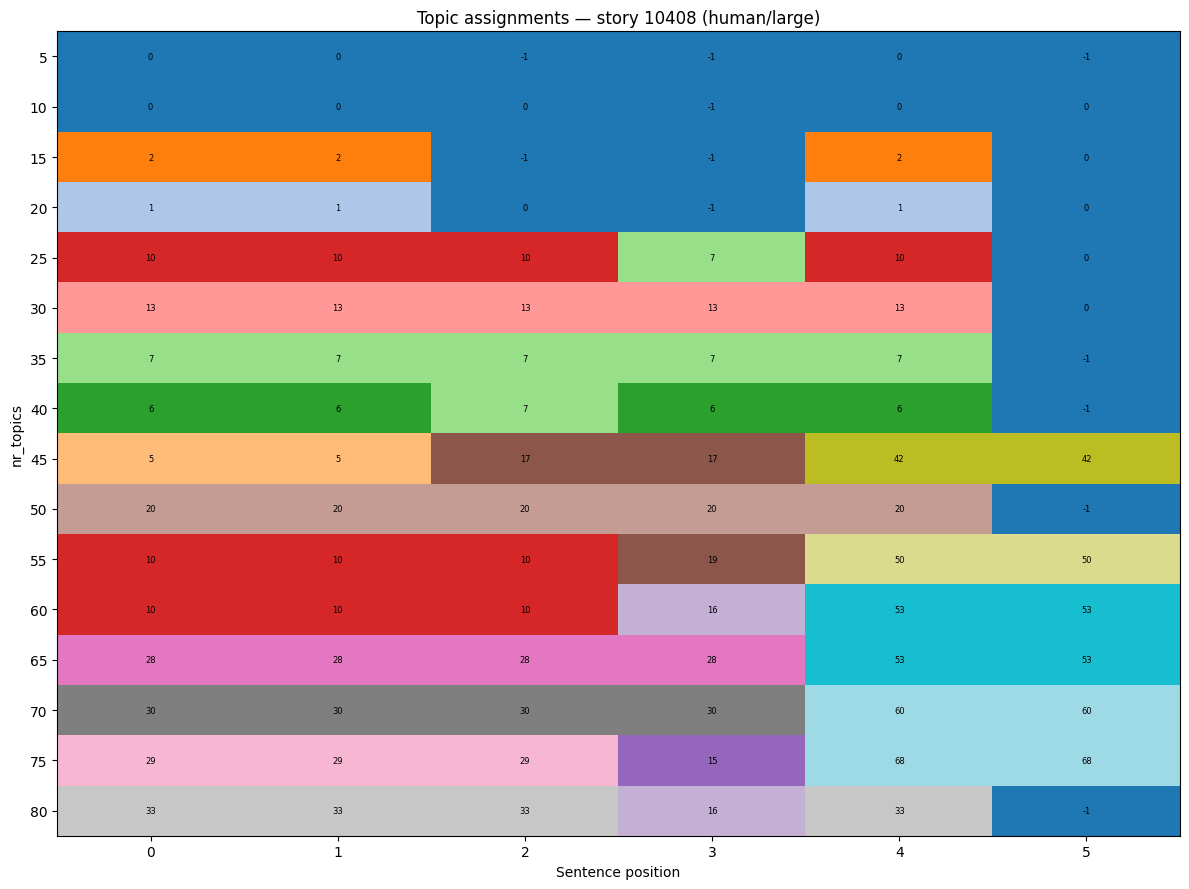

In [43]:
# ── Heatmap: topic ids across nr_topics x sentence position ──
if not df_nt.empty:
    fig, ax = plt.subplots(figsize=(max(12, n_sents * 0.6), len(pivot) * 0.5 + 1))

    # Use a categorical colormap
    all_topic_ids = sorted(df_nt['topic'].unique())
    n_colors = max(len(all_topic_ids), 1)
    cmap = plt.cm.get_cmap('tab20', n_colors)
    topic_to_idx = {t: i for i, t in enumerate(all_topic_ids)}

    matrix = pivot.values.copy().astype(float)
    matrix_mapped = np.vectorize(lambda t: topic_to_idx.get(int(t), -1))(matrix)

    im = ax.imshow(matrix_mapped, aspect='auto', cmap=cmap, interpolation='nearest')

    # Annotate with topic ids
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, str(int(matrix[i, j])), ha='center', va='center', fontsize=6)

    ax.set_yticks(range(len(pivot)))
    ax.set_yticklabels(pivot.index)
    ax.set_ylabel('nr_topics')
    ax.set_xlabel('Sentence position')
    ax.set_title(f'Topic assignments — story {STORY_ID_CMP} ({MODEL_TYPE_CMP}/{PROMPT_TYPE_CMP})')

    fig.tight_layout()
    plt.show()

bootstrap=0, nr_topics=30 (seed-filtered)
Total sentences (filtered): 4861
Unique topics assigned: 30
Outlier (topic -1): 529 (10.9%)


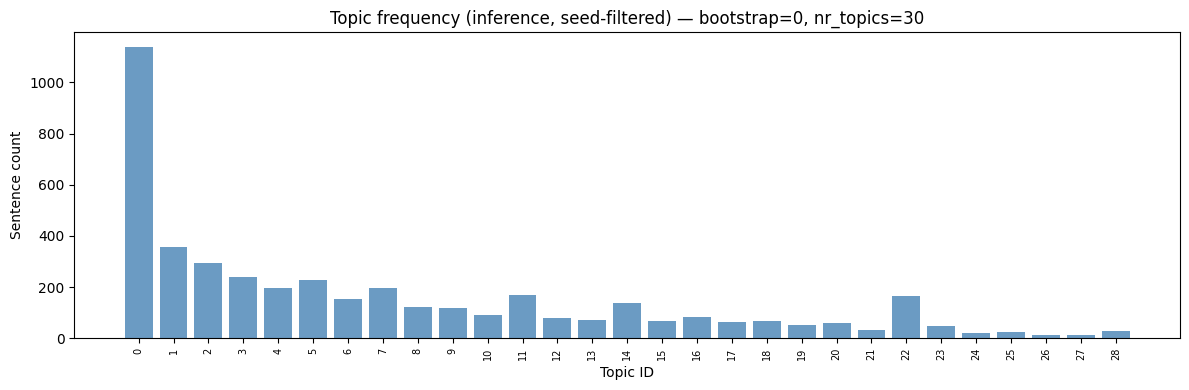

In [44]:
# ── Topic frequency across all stories for one config (seed-filtered) ──
AGG_BOOTSTRAP = 0
AGG_NR_TOPICS = 30

agg_infer_path = INFERENCE_DIR / f'bootstrap_{AGG_BOOTSTRAP:02d}' / f'topics_{AGG_NR_TOPICS}' / 'sentence_topics.npy'

if not agg_infer_path.exists():
    print(f'Not found: {agg_infer_path}')
else:
    all_topics = np.load(agg_infer_path)

    # Use seed-filtered sentences only
    filtered_indices = sent_map_filtered['sentence_idx'].values
    filtered_topics = all_topics[filtered_indices]
    topic_counts = pd.Series(filtered_topics).value_counts().sort_index()

    print(f'bootstrap={AGG_BOOTSTRAP}, nr_topics={AGG_NR_TOPICS} (seed-filtered)')
    print(f'Total sentences (filtered): {len(filtered_topics)}')
    print(f'Unique topics assigned: {len(topic_counts)}')
    print(f'Outlier (topic -1): {(filtered_topics == -1).sum()} ({(filtered_topics == -1).mean():.1%})')

    fig, ax = plt.subplots(figsize=(12, 4))
    non_outlier = topic_counts[topic_counts.index != -1]
    ax.bar(non_outlier.index.astype(str), non_outlier.values, color='steelblue', alpha=0.8)
    ax.set_xlabel('Topic ID')
    ax.set_ylabel('Sentence count')
    ax.set_title(f'Topic frequency (inference, seed-filtered) — bootstrap={AGG_BOOTSTRAP}, nr_topics={AGG_NR_TOPICS}')
    plt.xticks(rotation=90, fontsize=7)
    fig.tight_layout()
    plt.show()

In [45]:
# ── Per-condition topic distribution (seed-filtered) ──
if agg_infer_path.exists():
    df_with_topics = sent_map_filtered.copy()
    df_with_topics['topic'] = all_topics[df_with_topics['sentence_idx'].values]

    # Topic counts by model_type x prompt_type
    condition_topics = (
        df_with_topics.groupby(['model_type', 'prompt_type', 'topic'])
        .size()
        .reset_index(name='count')
    )

    # Outlier rate by condition
    outlier_rates = (
        df_with_topics.groupby(['model_type', 'prompt_type'])
        .apply(lambda g: (g['topic'] == -1).mean())
        .reset_index(name='outlier_rate')
        .sort_values('outlier_rate', ascending=False)
    )

    print(f'Outlier rate by condition (bootstrap={AGG_BOOTSTRAP}, nr_topics={AGG_NR_TOPICS}, seed-filtered):')
    display(outlier_rates)

    # Unique topics per condition
    unique_per_cond = (
        df_with_topics[df_with_topics['topic'] != -1]
        .groupby(['model_type', 'prompt_type'])['topic']
        .nunique()
        .reset_index(name='n_unique_topics')
        .sort_values('n_unique_topics', ascending=False)
    )
    print(f'\nUnique topics per condition:')
    display(unique_per_cond)

Outlier rate by condition (bootstrap=0, nr_topics=30, seed-filtered):


,model_type,prompt_type,outlier_rate
5,human,original,0.212644
11,qwen3vl,original,0.196429
4,human,large,0.175439
8,llama4scout,large,0.116095
3,gpt4o,original,0.095238
7,internvl3,original,0.084034
6,internvl3,large,0.081744
2,gpt4o,large,0.072674
9,llama4scout,original,0.058997
10,qwen3vl,large,0.043605



Unique topics per condition:


,model_type,prompt_type,n_unique_topics
7,internvl3,original,28
4,human,large,28
3,gpt4o,original,27
2,gpt4o,large,27
6,internvl3,large,27
11,qwen3vl,original,27
10,qwen3vl,large,26
0,claude45,large,26
1,claude45,original,25
5,human,original,25


In [46]:
# ── Compare topic sequences for the same story across models (seed-filtered) ──
CMP_STORY_ID = 10408
CMP_PROMPT = 'large'
CMP_BOOTSTRAP = 0
CMP_NR_TOPICS = 30

cmp_infer_path = INFERENCE_DIR / f'bootstrap_{CMP_BOOTSTRAP:02d}' / f'topics_{CMP_NR_TOPICS}' / 'sentence_topics.npy'

if not cmp_infer_path.exists():
    print(f'Not found: {cmp_infer_path}')
else:
    all_topics_cmp = np.load(cmp_infer_path)

    # Get all models that have this story_id + prompt (seed-filtered)
    story_all_models = sent_map_filtered[
        (sent_map_filtered['story_id'].astype(str) == str(CMP_STORY_ID))
        & (sent_map_filtered['prompt_type'] == CMP_PROMPT)
    ].copy()
    story_all_models['topic'] = all_topics_cmp[story_all_models['sentence_idx'].values]

    models_available = sorted(story_all_models['model_type'].unique())
    print(f'Story {CMP_STORY_ID}, prompt={CMP_PROMPT}, nr_topics={CMP_NR_TOPICS} (seed-filtered)')
    print(f'Models available: {models_available}')
    print()

    for model in models_available:
        sub = story_all_models[story_all_models['model_type'] == model].sort_values('sentence_pos')
        seeds = sorted(sub['seed'].unique())
        # For human-large: show per-seed then average
        if model == 'human' and len(seeds) > 1:
            all_srs = []
            for seed in seeds:
                sub_seed = sub[sub['seed'] == seed].sort_values('sentence_pos')
                topics_seq = sub_seed['topic'].values
                n_sw = sum(1 for i in range(len(topics_seq) - 1) if topics_seq[i] != topics_seq[i+1])
                sr = np.tanh(n_sw / (len(topics_seq) - 1)) if len(topics_seq) > 1 else 0
                all_srs.append(sr)
                print(f'{model:>20s} (seed={seed}): {len(sub_seed)} sents, {len(set(topics_seq))} unique topics, '
                      f'{n_sw} switches, switch_rate={sr:.3f}')
                print(f'{" " * 22}topics: {list(topics_seq)}')
            print(f'{model:>20s}   avg switch_rate={np.mean(all_srs):.3f}')
        else:
            topics_seq = sub['topic'].values
            n_sw = sum(1 for i in range(len(topics_seq) - 1) if topics_seq[i] != topics_seq[i+1])
            sr = np.tanh(n_sw / (len(topics_seq) - 1)) if len(topics_seq) > 1 else 0
            print(f'{model:>20s}: {len(sub)} sents, {len(set(topics_seq))} unique topics, '
                  f'{n_sw} switches, switch_rate={sr:.3f}')
            print(f'{" " * 22}topics: {list(topics_seq)}')
        print()

Story 10408, prompt=large, nr_topics=30 (seed-filtered)
Models available: ['claude45', 'gpt4o', 'human', 'internvl3', 'llama4scout', 'qwen3vl']

            claude45: 6 sents, 2 unique topics, 1 switches, switch_rate=0.197
                      topics: [np.int64(13), np.int64(13), np.int64(13), np.int64(13), np.int64(13), np.int64(0)]

               gpt4o: 6 sents, 2 unique topics, 1 switches, switch_rate=0.197
                      topics: [np.int64(13), np.int64(13), np.int64(13), np.int64(13), np.int64(13), np.int64(-1)]

               human (seed=42): 6 sents, 2 unique topics, 1 switches, switch_rate=0.197
                      topics: [np.int64(13), np.int64(13), np.int64(13), np.int64(13), np.int64(13), np.int64(0)]
               human (seed=43): 6 sents, 2 unique topics, 2 switches, switch_rate=0.380
                      topics: [np.int64(13), np.int64(13), np.int64(13), np.int64(13), np.int64(22), np.int64(13)]
               human (seed=44): 5 sents, 1 unique topics, 0 swi